In [11]:
pip install vaderSentiment

Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'


In [13]:
# Loading data 

df = pd.read_csv("/kaggle/input/datasets/sangharshnikam/nlp-dataset/ipl_cleaned.csv")
print(f"Matches loaded: {len(df)}\n")

analyzer = SentimentIntensityAnalyzer()

Matches loaded: 1090



# Step 2 : Generate Match Narrative From Match Facts

In [14]:
print("[Step 1] Generating match narratives...")
 
def generate_narrative(row):
    parts = []
 
    winner  = str(row.get("winner", ""))
    team1   = str(row.get("team1", ""))
    team2   = str(row.get("team2", ""))
    loser   = team2 if winner == team1 else team1
 
    # Toss
    toss_dec = str(row.get("toss_decision", ""))
    toss_win = str(row.get("toss_winner", ""))
    if toss_dec == "field":
        parts.append(f"{toss_win} won the toss and chose to field — a smart defensive move.")
    else:
        parts.append(f"{toss_win} won the toss and chose to bat aggressively.")
 
    # 1st innings score
    inn1      = float(row.get("inn1_runs", 0) or 0)
    inn1_wkts = float(row.get("inn1_wickets", 10) or 10)
    if inn1 >= 200:
        parts.append(f"An explosive innings of {int(inn1)} runs set a massive, daunting target!")
    elif inn1 >= 175:
        parts.append(f"A strong total of {int(inn1)} runs was posted.")
    elif inn1 >= 150:
        parts.append(f"A competitive total of {int(inn1)} runs was put up.")
    else:
        parts.append(f"The batting side struggled, posting only {int(inn1)} runs.")
 
    if inn1_wkts <= 3:
        parts.append("The batting team dominated, barely losing any wickets — outstanding!")
    elif inn1_wkts >= 9:
        parts.append("Bowlers fought brilliantly, taking many wickets to restrict the batting side.")
 
    # Sixes
    inn1_sixes  = float(row.get("inn1_sixes", 0) or 0)
    inn2_sixes  = float(row.get("inn2_sixes", 0) or 0)
    total_sixes = int(inn1_sixes + inn2_sixes)
    if total_sixes >= 20:
        parts.append(f"Fans were thrilled by {total_sixes} sixes — spectacular power hitting!")
    elif total_sixes >= 12:
        parts.append(f"The match featured {total_sixes} sixes, entertaining the crowd.")
 
    # Result — uses result + win_margin (NOT win_by_runs / win_by_wickets)
    result     = str(row.get("result", "")).lower()
    win_margin = float(row.get("win_margin", 0) or 0)
 
    if result == "runs":
        if win_margin >= 100:
            parts.append(f"{winner} crushed {loser} by {int(win_margin)} runs — a one-sided match.")
        elif win_margin >= 50:
            parts.append(f"{winner} beat {loser} by {int(win_margin)} runs in a comfortable victory.")
        elif win_margin >= 1:
            parts.append(f"{winner} won a thrilling nail-biting contest by just {int(win_margin)} runs!")
    elif result == "wickets":
        if win_margin >= 8:
            parts.append(f"{winner} chased down the target easily, winning by {int(win_margin)} wickets.")
        elif win_margin >= 5:
            parts.append(f"{winner} won by {int(win_margin)} wickets in an exciting chase.")
        elif win_margin >= 1:
            parts.append(f"{winner} won a nerve-wracking heart-stopping match by just {int(win_margin)} wickets!")
    elif result == "tie":
        parts.append("The match ended in a dramatic tie! Super Over decided the winner.")
 
    # High scoring
    total = float(row.get("total_match_runs", 0) or 0)
    if total >= 400:
        parts.append("A record-breaking high-scoring thriller — cricket at its finest!")
 
    # Close match
    cat = str(row.get("win_margin_category", ""))
    if "Close" in cat:
        parts.append("A closely contested match that kept everyone on the edge of their seats!")
 
    return " ".join(parts)
 
df["match_narrative"] = df.apply(generate_narrative, axis=1)
print(f"Narratives generated: {len(df)}")
print("\nSample narrative:")
print(df["match_narrative"].iloc[3])

[Step 1] Generating match narratives...
Narratives generated: 1090

Sample narrative:
Mumbai Indians won the toss and chose to bat aggressively. A competitive total of 165 runs was put up. Royal Challengers Bengaluru won by 5 wickets in an exciting chase.


# Step 3: Vader Sentiment on Narratives


In [15]:
def score_sentiment(text):
    s = analyzer.polarity_scores(str(text))
    return pd.Series({
        "compound" : round(s["compound"], 4),
        "positive" : round(s["pos"], 4),
        "negative" : round(s["neg"], 4),
        "neutral"  : round(s["neu"], 4),
    })
 
scores = df["match_narrative"].apply(score_sentiment)
df     = pd.concat([df, scores], axis=1)
 
def classify_excitement(score):
    if score >= 0.6:   return "Very Exciting"
    elif score >= 0.3: return "Exciting"
    elif score >= 0.0: return "Neutral"
    else:              return "Low-key"
 
df["excitement_level"] = df["compound"].apply(classify_excitement)
 
print("Excitement distribution:")
print(df["excitement_level"].value_counts().to_string())
print(f"\nAvg compound score : {df['compound'].mean():.3f}")
print(f"Max compound score : {df['compound'].max():.3f}")
print(f"Min compound score : {df['compound'].min():.3f}")
 

Excitement distribution:
excitement_level
Very Exciting    1088
Neutral             1
Exciting            1

Avg compound score : 0.916
Max compound score : 0.984
Min compound score : 0.273



# Step 4: Team-level Sentiment

In [20]:
team_sent = pd.concat([
    df[["team1","compound"]].rename(columns={"team1":"team"}),
    df[["team2","compound"]].rename(columns={"team2":"team"}),
]).groupby("team").agg(
    matches = ("compound","count"),
    avg_excitement = ("compound","mean"),
    exciting_matches = ("compound",lambda x:(x>=0.5).sum()),
).reset_index()

team_sent["excitement_rate"] = (
    team_sent["exciting_matches"] / team_sent["matches"] *100
).round(1)

team_sent["avg_excitement"] = team_sent["avg_excitement"].round(4)
team_sent = team_sent.sort_values("avg_excitement",ascending=False)

print("Top 5 team by avg match excitement:")
print(team_sent.head(5)[["team","matches","avg_excitement","excitement_rate"]].to_string(index=False))


Top 5 team by avg match excitement:
                       team  matches  avg_excitement  excitement_rate
       Lucknow Super Giants       43          0.9473            100.0
        Chennai Super Kings      237          0.9435            100.0
              Gujarat Lions       30          0.9291            100.0
Royal Challengers Bengaluru      252          0.9227             99.6
               Punjab Kings      246          0.9204            100.0


# Step 5: PLAYER OF MATCH EXCITEMENT

In [21]:
pom = (df[df["player_of_match"].notna()]
      .groupby("player_of_match").agg(
          awards = ("compound","count"),
          avg_excitement = ("compound","mean"),
      ).reset_index())

pom["avg_excitement"] = pom["avg_excitement"].round(4)
pom_top = pom[pom["awards"] >=5].sort_values("avg_excitement",ascending=False)

print("Top 10 POM by match excitement:")
print(pom_top.head(10)[["player_of_match","awards","avg_excitement"]].to_string(index=False))


Top 10 POM by match excitement:
player_of_match  awards  avg_excitement
       MS Dhoni      17          0.9600
     RD Gaikwad      11          0.9566
       SK Raina      14          0.9555
      DA Miller       5          0.9547
      RA Jadeja      16          0.9498
     MEK Hussey      12          0.9492
   F du Plessis      10          0.9470
      BA Stokes       5          0.9445
     GJ Maxwell       9          0.9441
     MP Stoinis       9          0.9429


# Step 6: SEASON SENTIMENT TREND


In [23]:
season_sent = df.groupby("season").agg(
    avg_excitement = ("compound","count"),
    high_scoring = ("high_scoring_match","sum"),
    exciting_count = ("excitement_level",lambda x:(x == "Very Exciting").sum()),
    matches = ("match_id","count")
).reset_index().round(3)

print(season_sent[["season","avg_excitement","exciting_count","matches"]].to_string(index=False))


 season  avg_excitement  exciting_count  matches
   2007              58              58       58
   2009             117             117      117
   2011              72              72       72
   2012              74              74       74
   2013              76              76       76
   2014              60              60       60
   2015              57              57       57
   2016              60              60       60
   2017              59              59       59
   2018              60              60       60
   2019              59              59       59
   2020              60              60       60
   2021              60              60       60
   2022              74              74       74
   2023              73              72       73
   2024              71              70       71


# Step 7: Charts - Opent to Screen

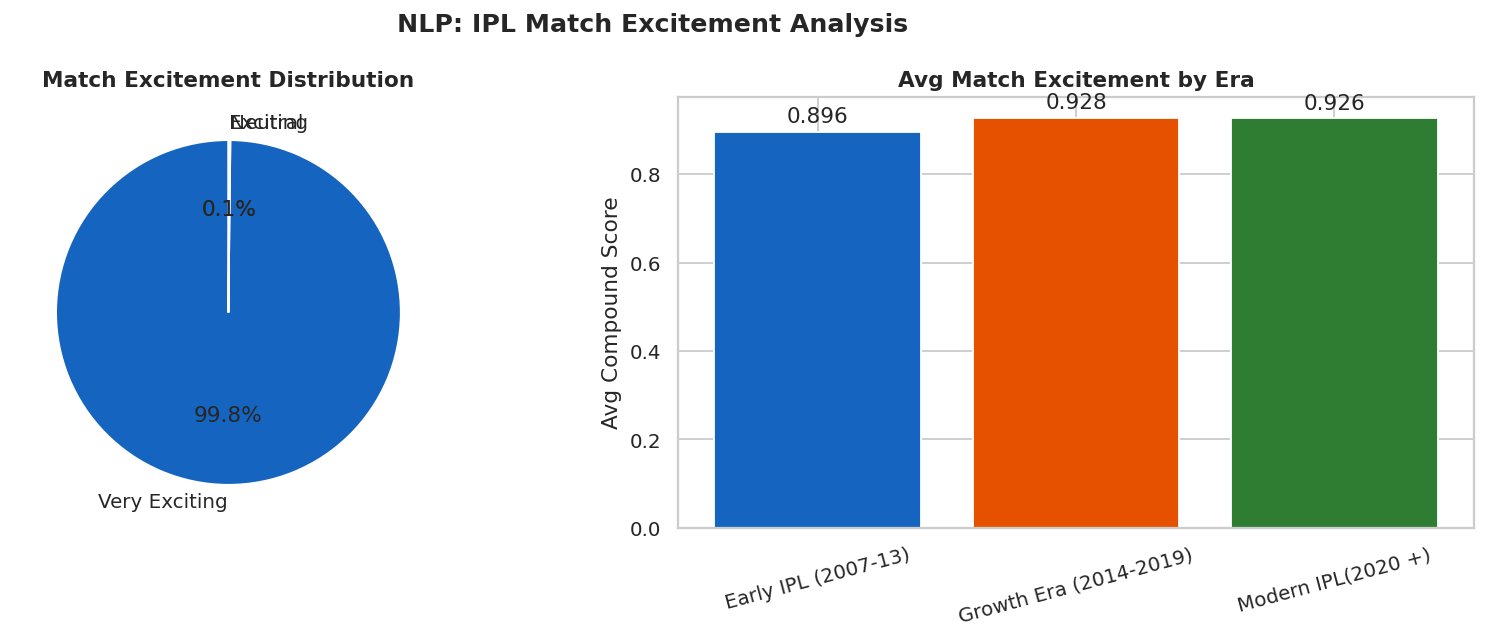

In [26]:
# Chart A : Excitement distribution  = by era
exc_counts = df["excitement_level"].value_counts()
exc_colors = ["#1565C0", "#2E7D32", "#F57F17", "#C62828"]

fig,axes = plt.subplots(1,2,figsize = (13,5))
axes[0].pie(exc_counts, labels=exc_counts.index, autopct="%1.1f%%",
            colors=exc_colors, startangle=90)
axes[0].set_title("Match Excitement Distribution", fontsize=12, fontweight="bold")
 
era_exc = df.groupby("era")["compound"].mean().round(3)
bars = axes[1].bar(era_exc.index, era_exc.values,
                   color=["#1565C0","#E65100","#2E7D32"], edgecolor="white")
axes[1].bar_label(bars, fmt="%.3f", padding=3)
axes[1].set_title("Avg Match Excitement by Era", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Avg Compound Score")
axes[1].tick_params(axis="x", rotation=15)
 
fig.suptitle("NLP: IPL Match Excitement Analysis",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

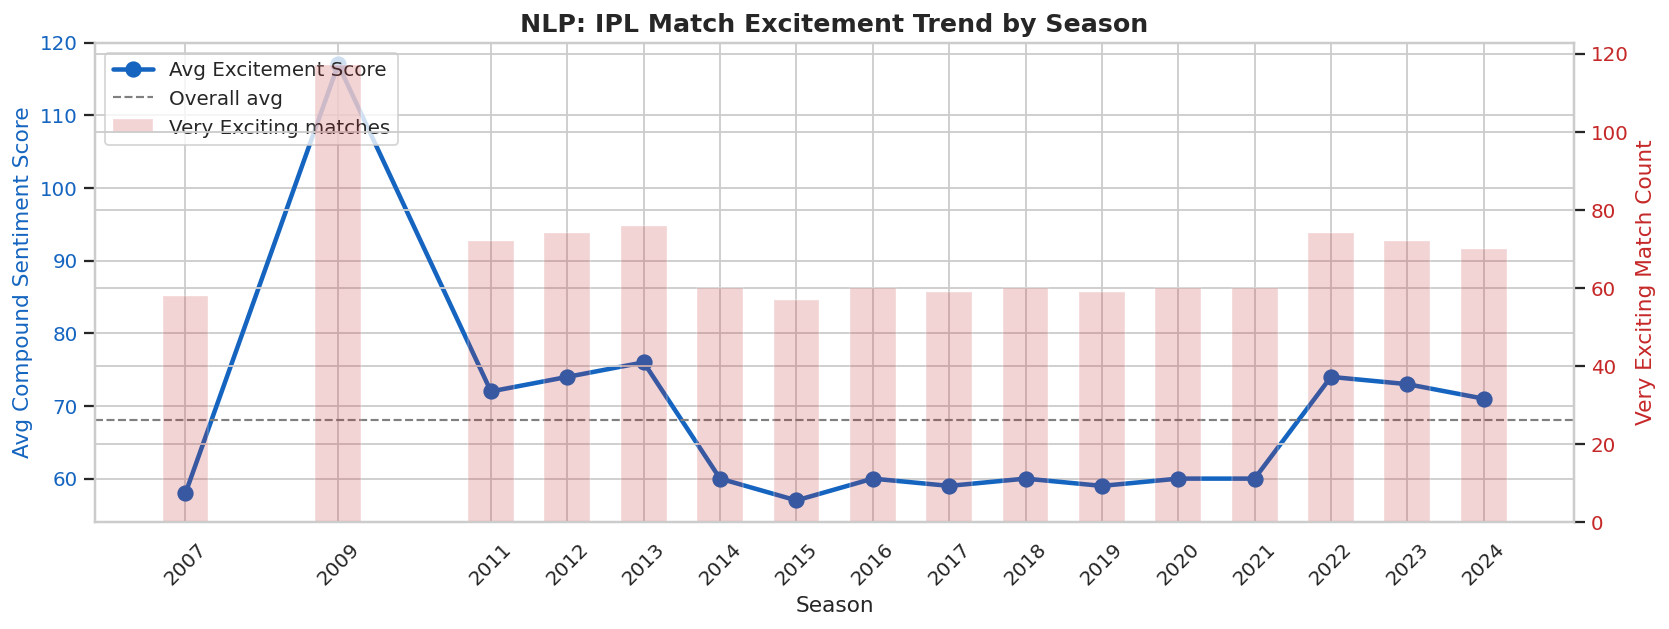

In [27]:
# ── Chart B: Season excitement trend ─────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(13, 5))
 
ax1.plot(season_sent["season"], season_sent["avg_excitement"],
         marker="o", color="#1565C0", linewidth=2.5,
         markersize=8, label="Avg Excitement Score")
ax1.axhline(season_sent["avg_excitement"].mean(),
            color="gray", linestyle="--", linewidth=1.2,
            label="Overall avg")
ax1.set_ylabel("Avg Compound Sentiment Score", color="#1565C0")
ax1.set_xlabel("Season")
ax1.set_xticks(season_sent["season"])
ax1.tick_params(axis="x", rotation=45)
ax1.tick_params(axis="y", labelcolor="#1565C0")
 
ax2 = ax1.twinx()
ax2.bar(season_sent["season"], season_sent["exciting_count"],
        alpha=0.2, color="#C62828", width=0.6,
        label="Very Exciting matches")
ax2.set_ylabel("Very Exciting Match Count", color="#C62828")
ax2.tick_params(axis="y", labelcolor="#C62828")
 
ax1.set_title("NLP: IPL Match Excitement Trend by Season",
              fontsize=14, fontweight="bold")
 
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()
 
 

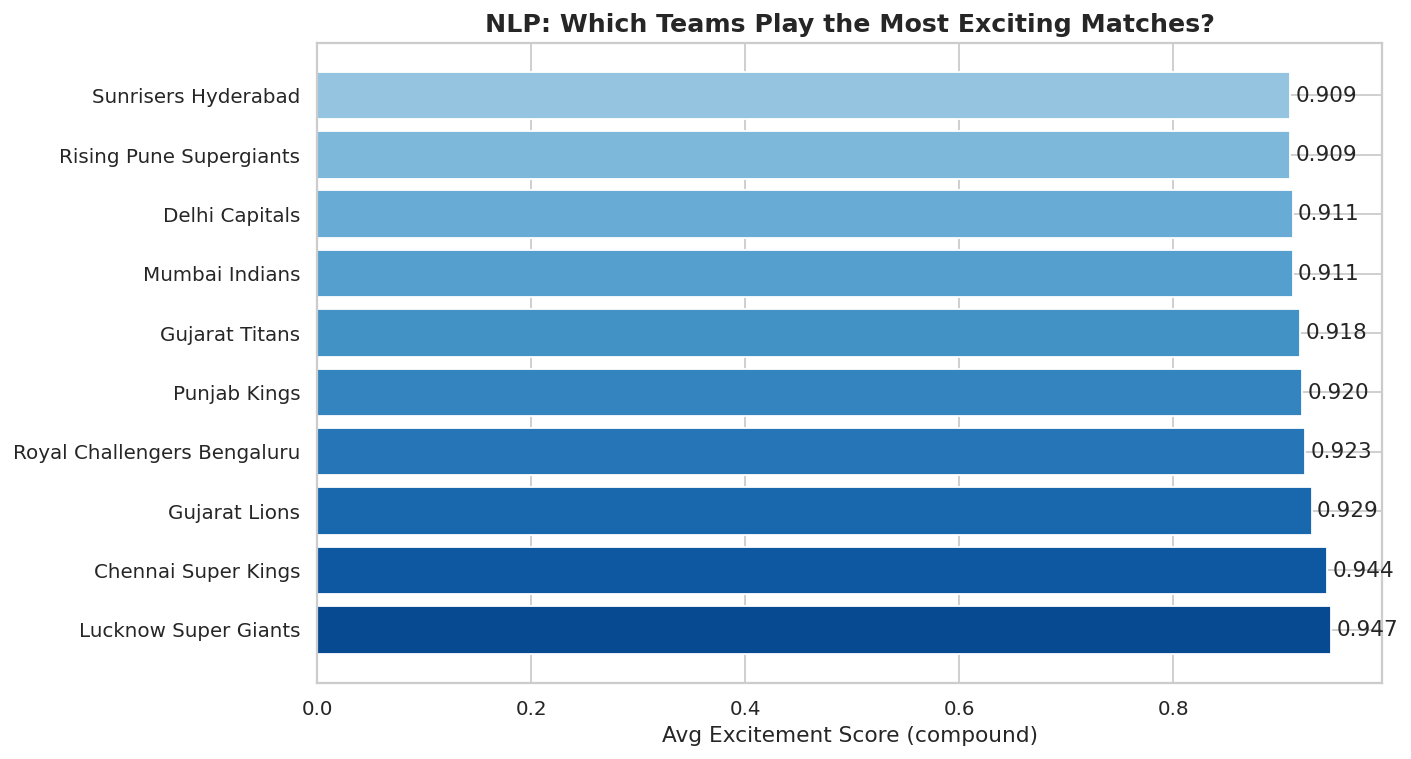

In [28]:
# ── Chart C: Top teams by excitement ─────────────────────────────────────────
top_teams = team_sent[team_sent["matches"] >= 20].head(10)
 
fig, ax = plt.subplots(figsize=(11, 6))
bar_colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_teams)))[::-1]
bars = ax.barh(top_teams["team"], top_teams["avg_excitement"],
               color=bar_colors, edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_xlabel("Avg Excitement Score (compound)")
ax.set_title("NLP: Which Teams Play the Most Exciting Matches?",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# ── Chart D: Top POM players by excitement ───────────────────────────────────
top_pom = pom_top.head(12)
 
fig, ax = plt.subplots(figsize=(12, 6))
bar_colors2 = plt.cm.Oranges(np.linspace(0.4, 0.9, len(top_pom)))[::-1]
bars = ax.bar(top_pom["player_of_match"], top_pom["avg_excitement"],
              color=bar_colors2, edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_title("NLP: Player of Match — Most Exciting Match Winners",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Player")
ax.set_ylabel("Avg Match Excitement Score")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()
 

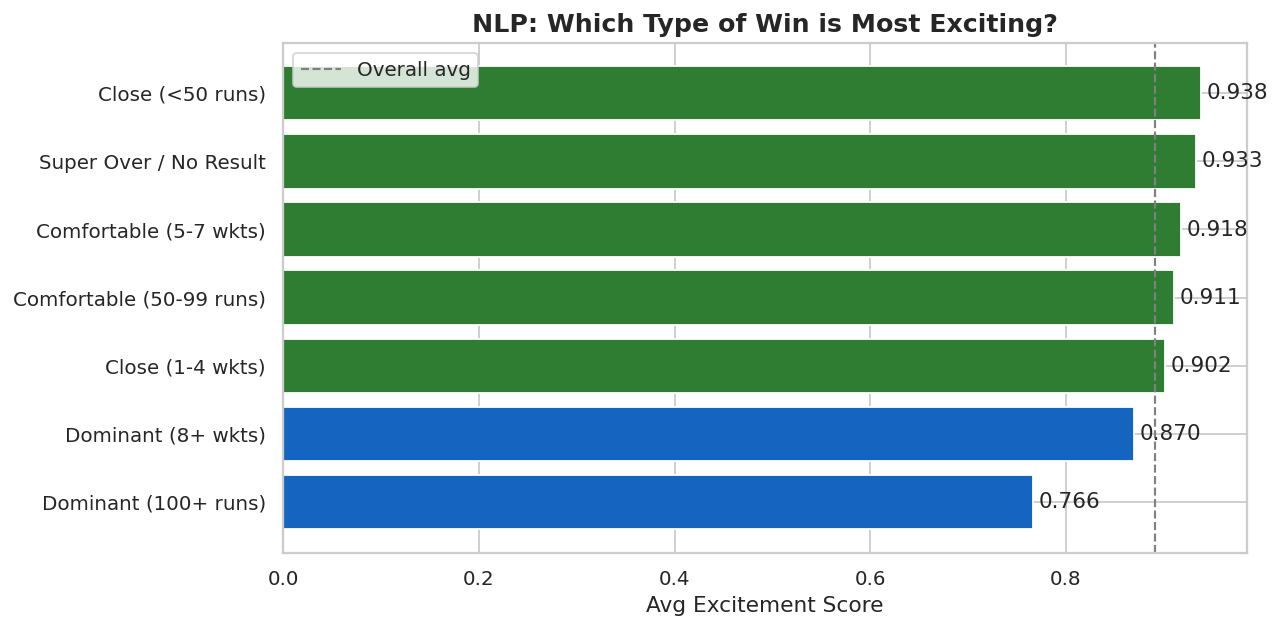

In [29]:

# ── Chart E: Excitement vs win margin category ────────────────────────────────
result_exc = df.groupby("win_margin_category")["compound"].mean().sort_values()
bar_colors3 = ["#2E7D32" if v > result_exc.mean() else "#1565C0"
               for v in result_exc.values]
 
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(result_exc.index, result_exc.values,
               color=bar_colors3, edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.axvline(result_exc.mean(), color="gray", linestyle="--",
           linewidth=1.2, label="Overall avg")
ax.set_xlabel("Avg Excitement Score")
ax.set_title("NLP: Which Type of Win is Most Exciting?",
             fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()
 

# SAVING ALL OUTPUT FILES

In [31]:
print("\n[Step 7] Saving output files...")

cols_keep = [
    "match_id","season","year","team1","team2","winner",
    "toss_winner","toss_decision","toss_won_match",
    "venue","city","player_of_match","era","match_type",
    "inn1_runs","inn2_runs","inn1_wickets","inn2_wickets",
    "inn1_sixes","inn2_sixes","total_match_runs","high_scoring_match",
    "result","win_margin","win_margin_category","chased_successfully",
    "match_narrative","compound","positive","negative","neutral",
    "excitement_level",
]

col_keep = [c for c in cols_keep if c in df.columns]

df[col_keep].to_csv("ipl_final.csv",index = False)
print("✅ SAVED: ipl_final.csv")

team_sent.to_csv("ipl_team_sentiment.csv", index=False)
print("✅ SAVED: ipl_team_sentiment.csv")
 
season_sent.to_csv("ipl_season_sentiment.csv", index=False)
print("✅ SAVED: ipl_season_sentiment.csv")
 
pom_top.to_csv("ipl_pom_excitement.csv", index=False)
print("✅ SAVED: ipl_pom_excitement.csv")

print("Power BI mein import karo:")
print("  ipl_final.csv           → main table (all match + sentiment)")
print("  ipl_team_sentiment.csv  → team excitement page")
print("  ipl_season_sentiment.csv → season trend page")
print("  ipl_pom_excitement.csv  → player analysis page")


[Step 7] Saving output files...
✅ SAVED: ipl_final.csv
✅ SAVED: ipl_team_sentiment.csv
✅ SAVED: ipl_season_sentiment.csv
✅ SAVED: ipl_pom_excitement.csv
Power BI mein import karo:
  ipl_final.csv           → main table (all match + sentiment)
  ipl_team_sentiment.csv  → team excitement page
  ipl_season_sentiment.csv → season trend page
  ipl_pom_excitement.csv  → player analysis page
